In [93]:
import pandas as pd

In [94]:
df_2023 = pd.read_csv("data/dam_settlement_prices_LZ_HOUSTON_2023.csv")
df_2024 = pd.read_csv("data/dam_settlement_prices_LZ_HOUSTON_2024.csv")

I augmented the DAM price dataset with daily ranking and scarcity indicators to construct realistic discharge commitments and quantify how buyback risk concentrates in tail price intervals.

In [95]:
import pandas as pd
import numpy as np

def add_dam_derived_features(
    df: pd.DataFrame,
    datetime_col: str = "datetime",
    price_col: str = "SettlementPointPrice",
    top_pct: float = 0.01,
    price_thresholds: tuple = (500, 1000),
    per_year_top_pct: bool = True,
) -> pd.DataFrame:
    """
    Add daily price stats/ranks and scarcity flags to an ERCOT DAM SPP dataframe,
    using an existing datetime column without adding extra time breakdown columns.

    Expected input columns (defaults):
      - datetime
      - SettlementPointPrice

    Returns a COPY of df with added columns:
      - daily_min_price, daily_max_price
      - daily_rank_low, daily_rank_high
      - price_gt_{threshold} for each threshold
      - top_{pct}_flag (global or per-year)
    """
    if datetime_col not in df.columns:
        raise KeyError(f"Missing datetime column '{datetime_col}'")
    if price_col not in df.columns:
        raise KeyError(f"Missing price column '{price_col}'")

    out = df.copy()

    # Ensure datetime dtype
    out[datetime_col] = pd.to_datetime(out[datetime_col], errors="coerce")
    if out[datetime_col].isna().any():
        bad = out[out[datetime_col].isna()].head(5)
        raise ValueError(
            f"Found non-parseable datetimes in '{datetime_col}'. Examples:\n{bad}"
        )

    # Sort for consistent downstream operations
    out = out.sort_values(datetime_col).reset_index(drop=True)

    # Daily min/max and ranks (grouped by calendar date derived from datetime_col)
    grp = out.groupby(out[datetime_col].dt.date)[price_col]
    out["daily_min_price"] = grp.transform("min")
    out["daily_max_price"] = grp.transform("max")

    out["daily_rank_low"] = grp.rank(method="first", ascending=True)
    out["daily_rank_high"] = grp.rank(method="first", ascending=False)

    # Threshold-based scarcity flags
    for thr in price_thresholds:
        col = f"price_gt_{int(thr)}"
        out[col] = out[price_col] > thr

    # Top-X% flag (global or per-year)
    pct = float(top_pct)
    if not (0 < pct < 1):
        raise ValueError("top_pct must be between 0 and 1 (e.g., 0.01 for top 1%)")

    flag_name = f"top_{int(round(pct * 100))}pct_flag"

    if per_year_top_pct:
        # e.g., each year has its own 99th percentile threshold
        q = 1 - pct
        out[flag_name] = out.groupby(out[datetime_col].dt.year)[price_col].transform(
            lambda x: x >= x.quantile(q)
        )
    else:
        q = 1 - pct
        thr = out[price_col].quantile(q)
        out[flag_name] = out[price_col] >= thr

    return out

In [96]:
df_2023 = add_dam_derived_features(df_2023)
df_2024 = add_dam_derived_features(df_2024)


In [97]:
# df_2023.index = df_2023['datetime']
# df_2024.index = df_2024['datetime']

In [98]:
df_2023.columns

Index(['datetime', 'SettlementPoint', 'SettlementPointPrice', 'DSTFlag',
       'daily_min_price', 'daily_max_price', 'daily_rank_low',
       'daily_rank_high', 'price_gt_500', 'price_gt_1000', 'top_1pct_flag'],
      dtype='object')

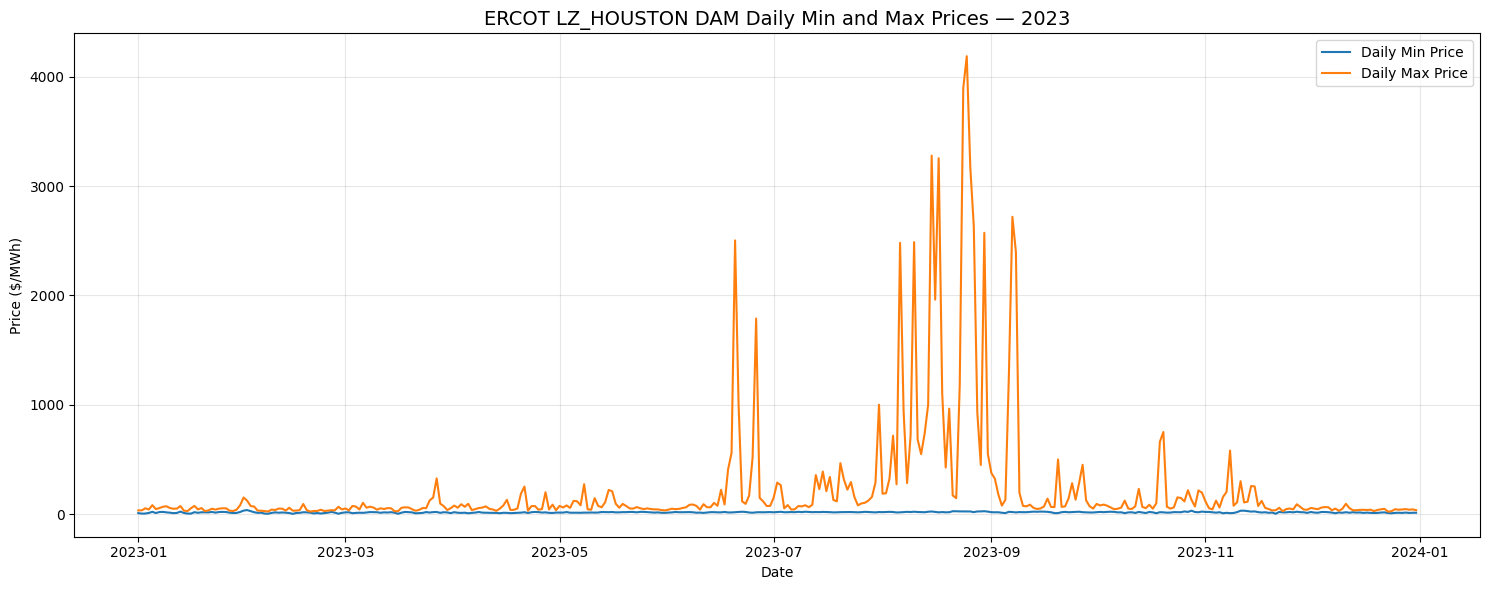

In [99]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a daily-level dataframe from datetime (no persistent extra columns)
daily_plot_2023 = (
    df_2023
    .assign(_date=df_2023["datetime"].dt.date)
    .groupby("_date", as_index=False)[["daily_min_price", "daily_max_price"]]
    .first()
    .rename(columns={"_date": "date"})
)

daily_plot_2023["date"] = pd.to_datetime(daily_plot_2023["date"])

plt.figure(figsize=(15, 6))

plt.plot(
    daily_plot_2023["date"],
    daily_plot_2023["daily_min_price"],
    label="Daily Min Price",
    linewidth=1.5
)

plt.plot(
    daily_plot_2023["date"],
    daily_plot_2023["daily_max_price"],
    label="Daily Max Price",
    linewidth=1.5
)

plt.title("ERCOT LZ_HOUSTON DAM Daily Min and Max Prices — 2023", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Price ($/MWh)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

You are modeling:

A rational merchant battery maximizing DAM arbitrage revenue under perfect price knowledge.

The DAM schedule is constructed using a simple daily arbitrage rule (charge in the two lowest-priced hours and discharge in the two highest-priced hours). This creates a transparent and reproducible baseline commitment against which physical feasibility and buyback risk are evaluated.

In [100]:
df_2023['price_gt_500'].value_counts()

price_gt_500
False    8635
True      125
Name: count, dtype: int64

In [101]:
def build_dam_schedule(df, power_mw=1, hours_to_dispatch=2):
    """
    Build a simple DAM arbitrage schedule:
    - Charge in lowest N hours per day
    - Discharge in highest N hours per day
    """

    df_schedule = df.copy()

    # Initialize
    df_schedule["dam_charge_mw"] = 0.0
    df_schedule["dam_discharge_mw"] = 0.0

    # Charge rule
    df_schedule.loc[df_schedule["daily_rank_low"] <= hours_to_dispatch, "dam_charge_mw"] = power_mw

    # Discharge rule
    df_schedule.loc[df_schedule["daily_rank_high"] <= hours_to_dispatch, "dam_discharge_mw"] = power_mw

    # Net position
    df_schedule["dam_net_position_mw"] = (
        df_schedule["dam_discharge_mw"] - df_schedule["dam_charge_mw"]
    )

    # Energy (1-hour intervals)
    df_schedule["dam_energy_mwh"] = df_schedule["dam_net_position_mw"]

    # Expected DAM revenue
    df_schedule["dam_expected_revenue"] = (
        df_schedule["dam_net_position_mw"] * df_schedule["SettlementPointPrice"]
    )

    return df_schedule

In [102]:
df_dam_schedule_2023 = build_dam_schedule(df_2023)
df_dam_schedule_2023.columns

Index(['datetime', 'SettlementPoint', 'SettlementPointPrice', 'DSTFlag',
       'daily_min_price', 'daily_max_price', 'daily_rank_low',
       'daily_rank_high', 'price_gt_500', 'price_gt_1000', 'top_1pct_flag',
       'dam_charge_mw', 'dam_discharge_mw', 'dam_net_position_mw',
       'dam_energy_mwh', 'dam_expected_revenue'],
      dtype='object')

Big Picture

You now have:

Dataset 1 → Market opportunity
Dataset 2 → Market commitment

Next comes:

Dataset 3 → Physical feasibility

That’s where buybacks live.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = df_dam_schedule_2023.copy()
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime")

np.float64(144342.42)

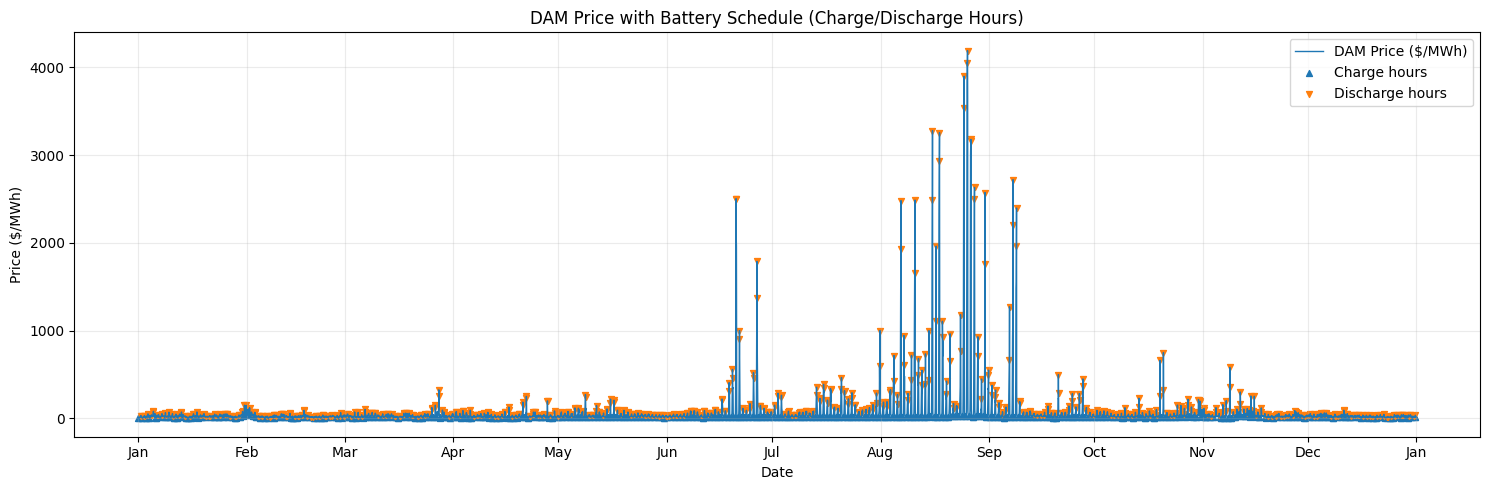

In [107]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df["datetime"], df["SettlementPointPrice"], linewidth=1.0, label="DAM Price ($/MWh)")

# Mark charge/discharge hours
charge = df["dam_charge_mw"] > 0
discharge = df["dam_discharge_mw"] > 0

ax.scatter(df.loc[charge, "datetime"], df.loc[charge, "SettlementPointPrice"],
           s=18, marker="^", label="Charge hours")
ax.scatter(df.loc[discharge, "datetime"], df.loc[discharge, "SettlementPointPrice"],
           s=18, marker="v", label="Discharge hours")

ax.set_title("DAM Price with Battery Schedule (Charge/Discharge Hours)")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($/MWh)")
ax.grid(alpha=0.25)
ax.legend()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()
plt.show()

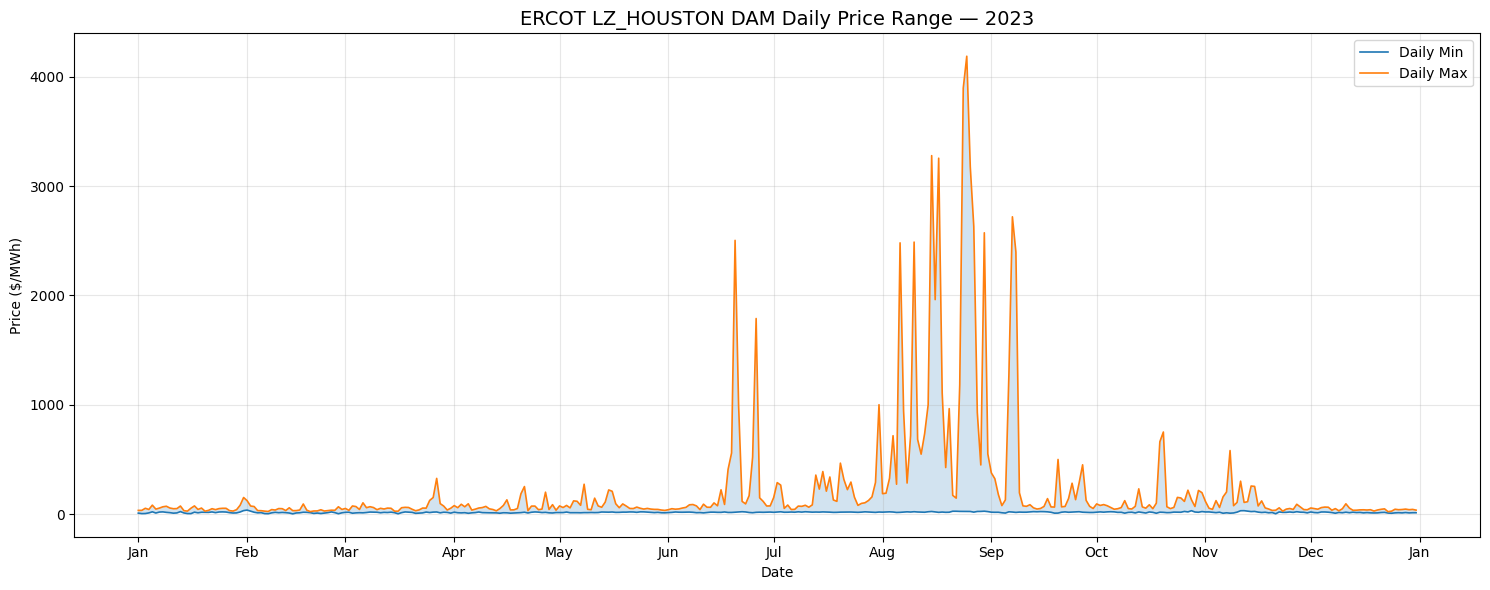

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Ensure datetime is correct
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime")

# Compute daily min/max directly from datetime
daily = (
    df.set_index("datetime")
      .resample("D")["SettlementPointPrice"]
      .agg(daily_min_price="min",
           daily_max_price="max")
      .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize=(15, 6))

ax.fill_between(
    daily["datetime"],
    daily["daily_min_price"],
    daily["daily_max_price"],
    alpha=0.2
)

ax.plot(
    daily["datetime"],
    daily["daily_min_price"],
    linewidth=1.2,
    label="Daily Min"
)

ax.plot(
    daily["datetime"],
    daily["daily_max_price"],
    linewidth=1.2,
    label="Daily Max"
)

ax.set_title("ERCOT LZ_HOUSTON DAM Daily Price Range — 2023", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price ($/MWh)")
ax.grid(alpha=0.3)
ax.legend()

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

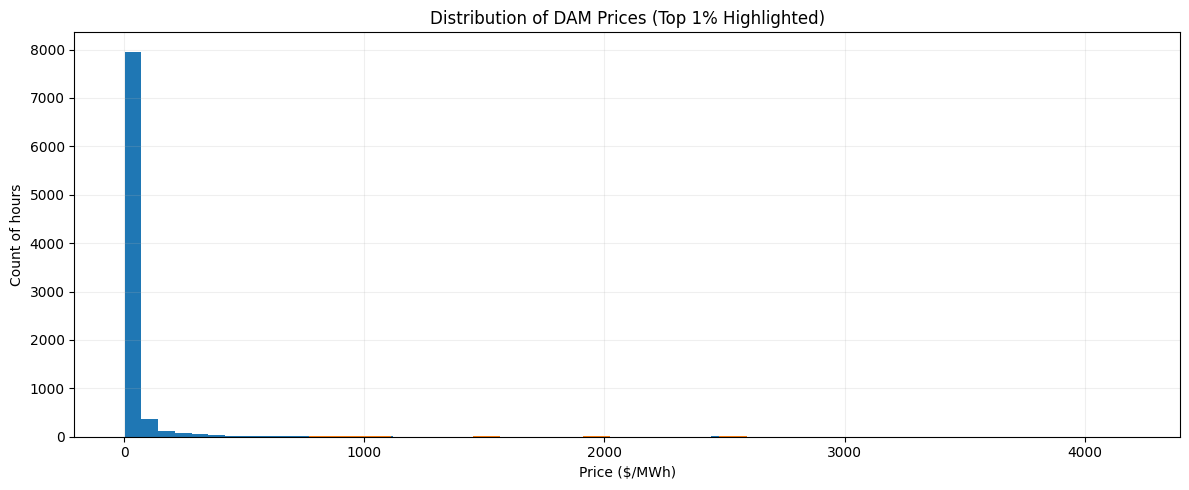

In [110]:
prices = df["SettlementPointPrice"].to_numpy()
tail = df.loc[df["top_1pct_flag"], "SettlementPointPrice"].to_numpy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(prices, bins=60)
ax.hist(tail, bins=30)

ax.set_title("Distribution of DAM Prices (Top 1% Highlighted)")
ax.set_xlabel("Price ($/MWh)")
ax.set_ylabel("Count of hours")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

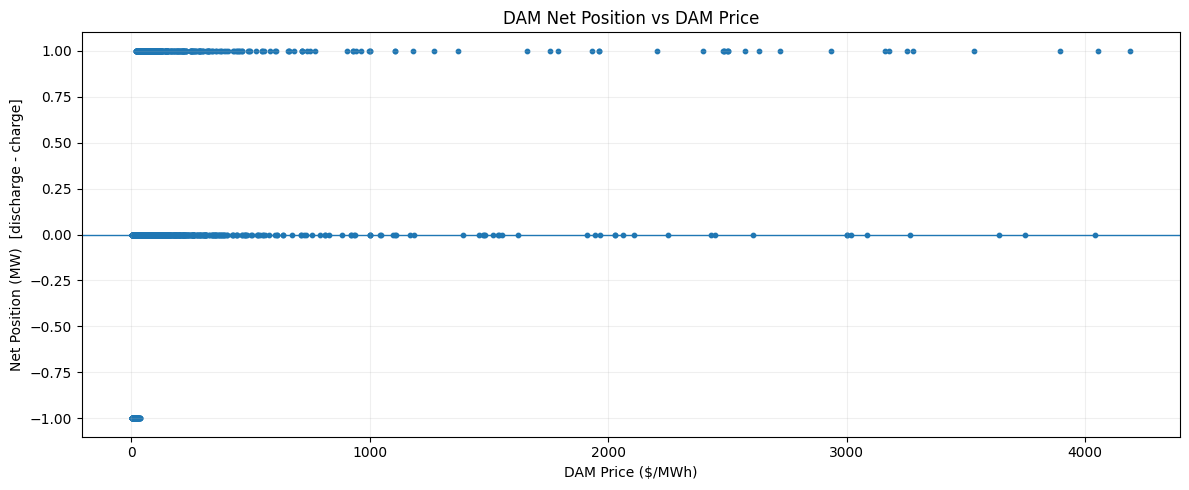

In [111]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.scatter(df["SettlementPointPrice"], df["dam_net_position_mw"], s=10)

ax.axhline(0, linewidth=1)
ax.set_title("DAM Net Position vs DAM Price")
ax.set_xlabel("DAM Price ($/MWh)")
ax.set_ylabel("Net Position (MW)  [discharge - charge]")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

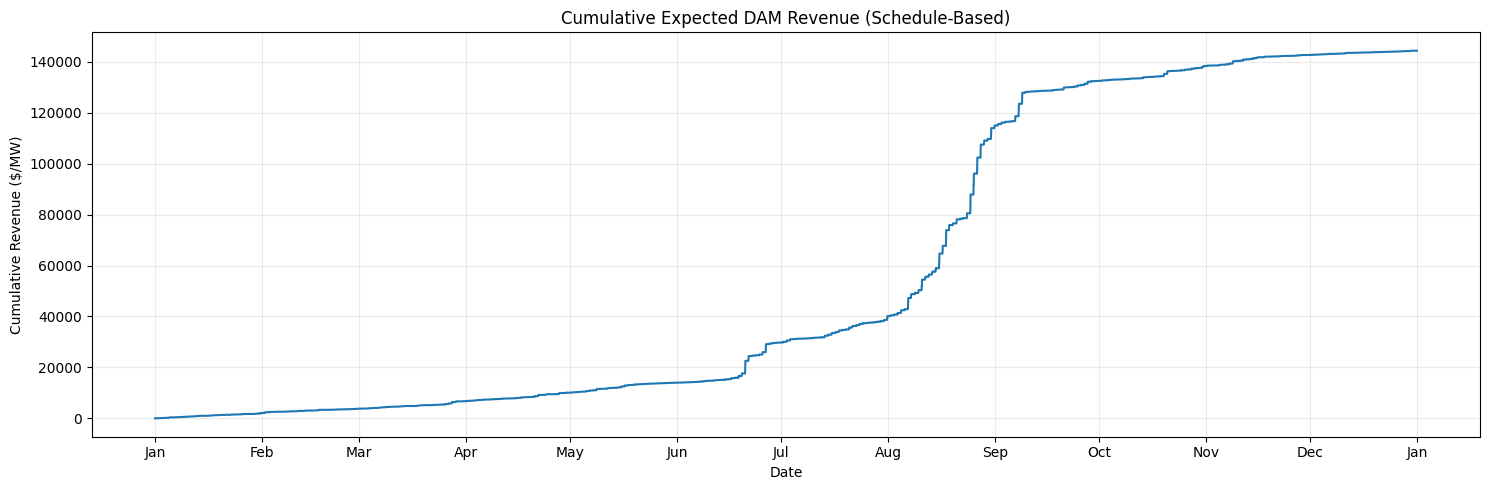

In [112]:
df["cum_expected_revenue"] = df["dam_expected_revenue"].cumsum()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(df["datetime"], df["cum_expected_revenue"], linewidth=1.5)

ax.set_title("Cumulative Expected DAM Revenue (Schedule-Based)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Revenue ($/MW)")
ax.grid(alpha=0.25)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()
plt.show()

In [115]:
df.columns

Index(['datetime', 'SettlementPoint', 'SettlementPointPrice', 'DSTFlag',
       'daily_min_price', 'daily_max_price', 'daily_rank_low',
       'daily_rank_high', 'price_gt_500', 'price_gt_1000', 'top_1pct_flag',
       'dam_charge_mw', 'dam_discharge_mw', 'dam_net_position_mw',
       'dam_energy_mwh', 'dam_expected_revenue'],
      dtype='object')

One wants to avoid not having sufficient capacity or SOC to meet the commitment, otherwise a battery owner would have to buy energy in real time which would be substantially more expensive.  

Which hours are most dangerous if delivery fails


?

You have:

Dataset 1 → Market prices

Dataset 2 → DAM commitment

Now Dataset 3 answers:

Given AS uncertainty, can the battery physically meet its DAM discharge commitments?